<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h1 style="text-align: center;"><b>Домашнее задание. Решение конкурса на kaggle</b></h1>

In [ ]:
from sklearn.metrics import roc_auc_score

y_true = [
    0,
    1,
    1,
    0,
    1
]

y_predictions = [
    0.1,
    0.9,
    0.4,
    0.6,
    0.61
]

roc_auc_score(y_true, y_predictions)

# Первая часть. Исследование

In [20]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import sklearn
from itertools import chain

## Загрузка данных (2 балла)

1) Посмотрите на случайные строчки.

2) Посмотрите, есть ли в датасете незаполненные значения (nan'ы) с помощью data.isna() или data.info() и, если нужно, замените их на что-то. Будет хорошо, если вы построите табличку с количеством nan в каждой колонке.

In [21]:
df = pd.read_csv('./train.csv')

df

,ClientPeriod,MonthlySpending,TotalSpent,Sex,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod,Churn
0,55,19.50,1026.35,Male,0,Yes,Yes,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,0
1,72,25.85,1872.2,Male,0,Yes,No,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),0
2,1,75.90,75.9,Male,0,No,No,Yes,No,Fiber optic,No,No,No,Yes,No,No,Month-to-month,Yes,Electronic check,1
3,32,79.30,2570,Female,1,Yes,No,Yes,Yes,Fiber optic,No,No,Yes,No,No,No,Month-to-month,No,Mailed check,0
4,60,115.25,6758.45,Female,0,Yes,Yes,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5277,3,30.40,82.15,Male,0,No,No,No,No phone service,DSL,No,No,No,Yes,No,No,Month-to-month,No,Electronic check,0
5278,50,44.45,2188.45,Male,0,Yes,No,No,No phone service,DSL,Yes,No,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),0
5279,1,55.05,55.05,Male,0,No,No,Yes,No,DSL,No,No,Yes,Yes,No,No,Month-to-month,No,Mailed check,0
5280,29,76.00,2215.25,Female,0,No,No,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Credit card (automatic),0


In [22]:
# Для вашего удобства списки с именами разных колонок

# Числовые признаки
num_cols = [
    'ClientPeriod',
    'MonthlySpending',
    'TotalSpent'
]

# Категориальные признаки
cat_cols = [
    'Sex',
    'IsSeniorCitizen',
    'HasPartner',
    'HasChild',
    'HasPhoneService',
    'HasMultiplePhoneNumbers',
    'HasInternetService',
    'HasOnlineSecurityService',
    'HasOnlineBackup',
    'HasDeviceProtection',
    'HasTechSupportAccess',
    'HasOnlineTV',
    'HasMovieSubscription',
    'HasContractPhone',
    'IsBillingPaperless',
    'PaymentMethod'
]

feature_cols = num_cols + cat_cols


from sklearn.model_selection import train_test_split

df_save = df.copy(True)
y = df.pop('Churn')
X = df.copy(deep=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)


df

,ClientPeriod,MonthlySpending,TotalSpent,Sex,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod
0,55,19.50,1026.35,Male,0,Yes,Yes,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check
1,72,25.85,1872.2,Male,0,Yes,No,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic)
2,1,75.90,75.9,Male,0,No,No,Yes,No,Fiber optic,No,No,No,Yes,No,No,Month-to-month,Yes,Electronic check
3,32,79.30,2570,Female,1,Yes,No,Yes,Yes,Fiber optic,No,No,Yes,No,No,No,Month-to-month,No,Mailed check
4,60,115.25,6758.45,Female,0,Yes,Yes,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5277,3,30.40,82.15,Male,0,No,No,No,No phone service,DSL,No,No,No,Yes,No,No,Month-to-month,No,Electronic check
5278,50,44.45,2188.45,Male,0,Yes,No,No,No phone service,DSL,Yes,No,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic)
5279,1,55.05,55.05,Male,0,No,No,Yes,No,DSL,No,No,Yes,Yes,No,No,Month-to-month,No,Mailed check
5280,29,76.00,2215.25,Female,0,No,No,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Credit card (automatic)


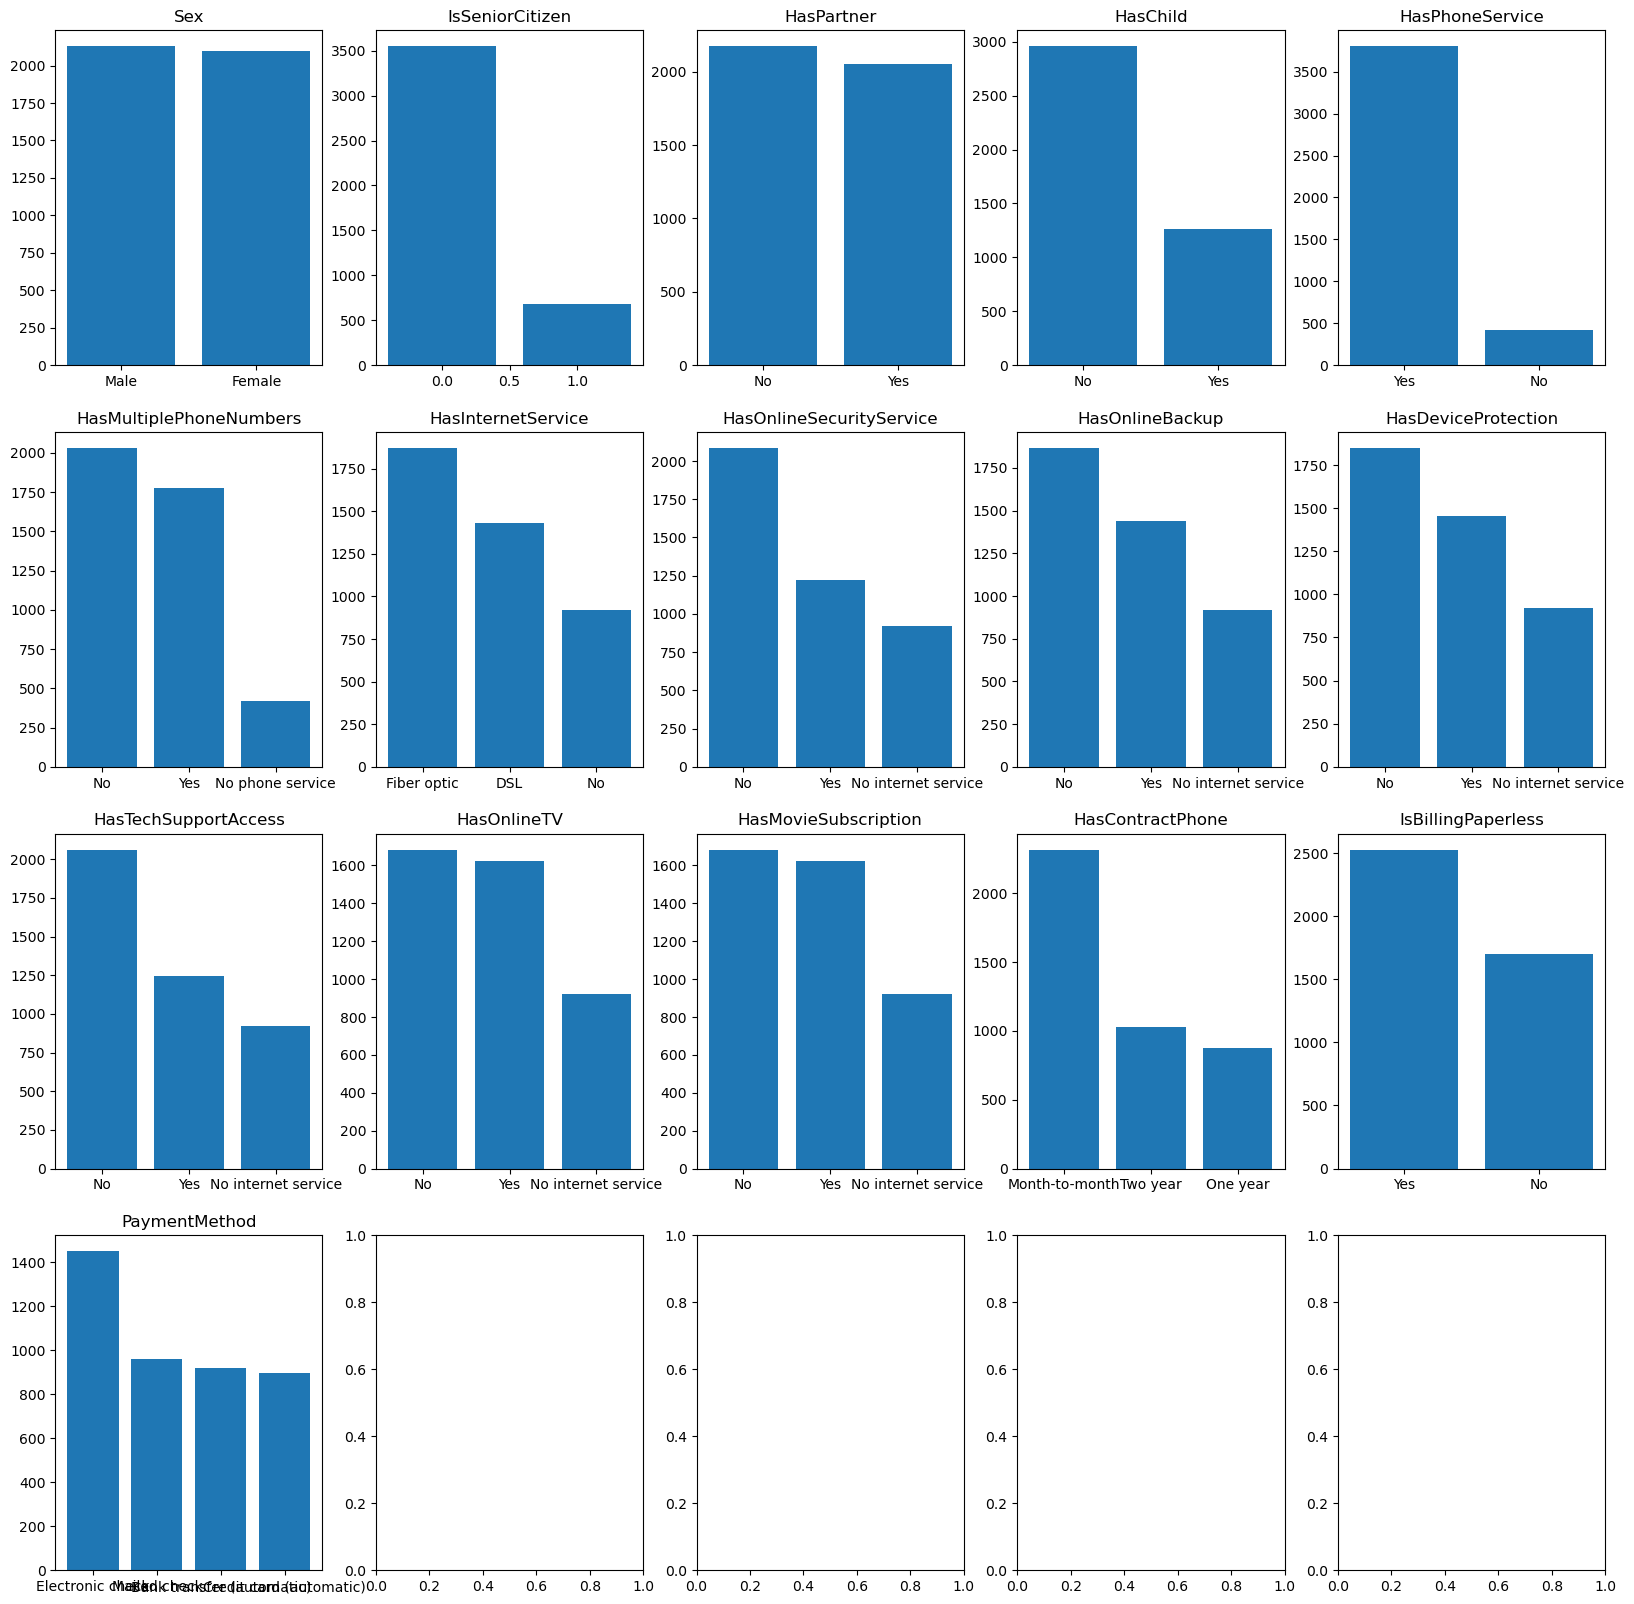

In [23]:
fig, axes = plt.subplots(4, 5, figsize=(20, 20))
for axis, col in zip(chain(*axes), X_train[cat_cols].columns):
    counts = X_train[col].value_counts()
    axis.set_title(col)
    axis.bar(counts.index, counts.values, width=0.8)

# Видим, что незаполненные значения в категориальных столбцах отсутствуют

In [24]:
print(X_train[num_cols].isna().sum()) # nan'ы отсутствуют

X_train[num_cols].info() # В TotalSpent тип object, но значения - дробные числа

ClientPeriod       0
MonthlySpending    0
TotalSpent         0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 4225 entries, 1835 to 1289
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ClientPeriod     4225 non-null   int64  
 1   MonthlySpending  4225 non-null   float64
 2   TotalSpent       4225 non-null   object 
dtypes: float64(1), int64(1), object(1)
memory usage: 132.0+ KB


In [25]:
# Заполним пропуски в TotalSpent средним значением столбца
mean_spent = X_train.TotalSpent.replace(' ', np.nan).dropna().astype(np.float64).describe()['mean']
X_train.TotalSpent = X_train.TotalSpent.replace(' ', mean_spent).astype(np.float64)

X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4225 entries, 1835 to 1289
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ClientPeriod              4225 non-null   int64  
 1   MonthlySpending           4225 non-null   float64
 2   TotalSpent                4225 non-null   float64
 3   Sex                       4225 non-null   object 
 4   IsSeniorCitizen           4225 non-null   int64  
 5   HasPartner                4225 non-null   object 
 6   HasChild                  4225 non-null   object 
 7   HasPhoneService           4225 non-null   object 
 8   HasMultiplePhoneNumbers   4225 non-null   object 
 9   HasInternetService        4225 non-null   object 
 10  HasOnlineSecurityService  4225 non-null   object 
 11  HasOnlineBackup           4225 non-null   object 
 12  HasDeviceProtection       4225 non-null   object 
 13  HasTechSupportAccess      4225 non-null   object 
 14  HasOnlineT

## Анализ данных (3 балла)

1) Для численных призанков постройте гистограмму (*plt.hist(...)*) или boxplot (*plt.boxplot(...)*). Для категориальных посчитайте количество каждого значения для каждого признака. Для каждой колонки надо сделать *data.value_counts()* и построить bar диаграммы *plt.bar(...)* или круговые диаграммы *plt.pie(...)* (хорошо, елси вы сможете это сделать на одном гарфике с помощью *plt.subplots(...)*).

2) Посмотрите на распределение целевой переменной и скажите, являются ли классы несбалансированными.

3) (Если будет желание) Поиграйте с разными библиотеками для визуализации - *sns*, *pandas_visual_analysis*, etc.

Второй пункт очень важен, потому что существуют задачи классификации с несбалансированными классами. Например, это может значить, что в датасете намного больше примеров 0 класса. В таких случаях нужно 1) не использовать accuracy как метрику 2) использовать методы борьбы с imbalanced dataset (обычно если датасет сильно несбалансирован, т.е. класса 1 в 20 раз меньше класса 0).

/var/folders/8y/tp0rp2tn4x31ymk1f4n8trg40000gn/T/ipykernel_45913/336064426.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_rate = X_train.join(y_train).groupby(bins)[y_train.name].mean()
/var/folders/8y/tp0rp2tn4x31ymk1f4n8trg40000gn/T/ipykernel_45913/336064426.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_rate = X_train.join(y_train).groupby(bins)[y_train.name].mean()
/var/folders/8y/tp0rp2tn4x31ymk1f4n8trg40000gn/T/ipykernel_45913/336064426.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False 

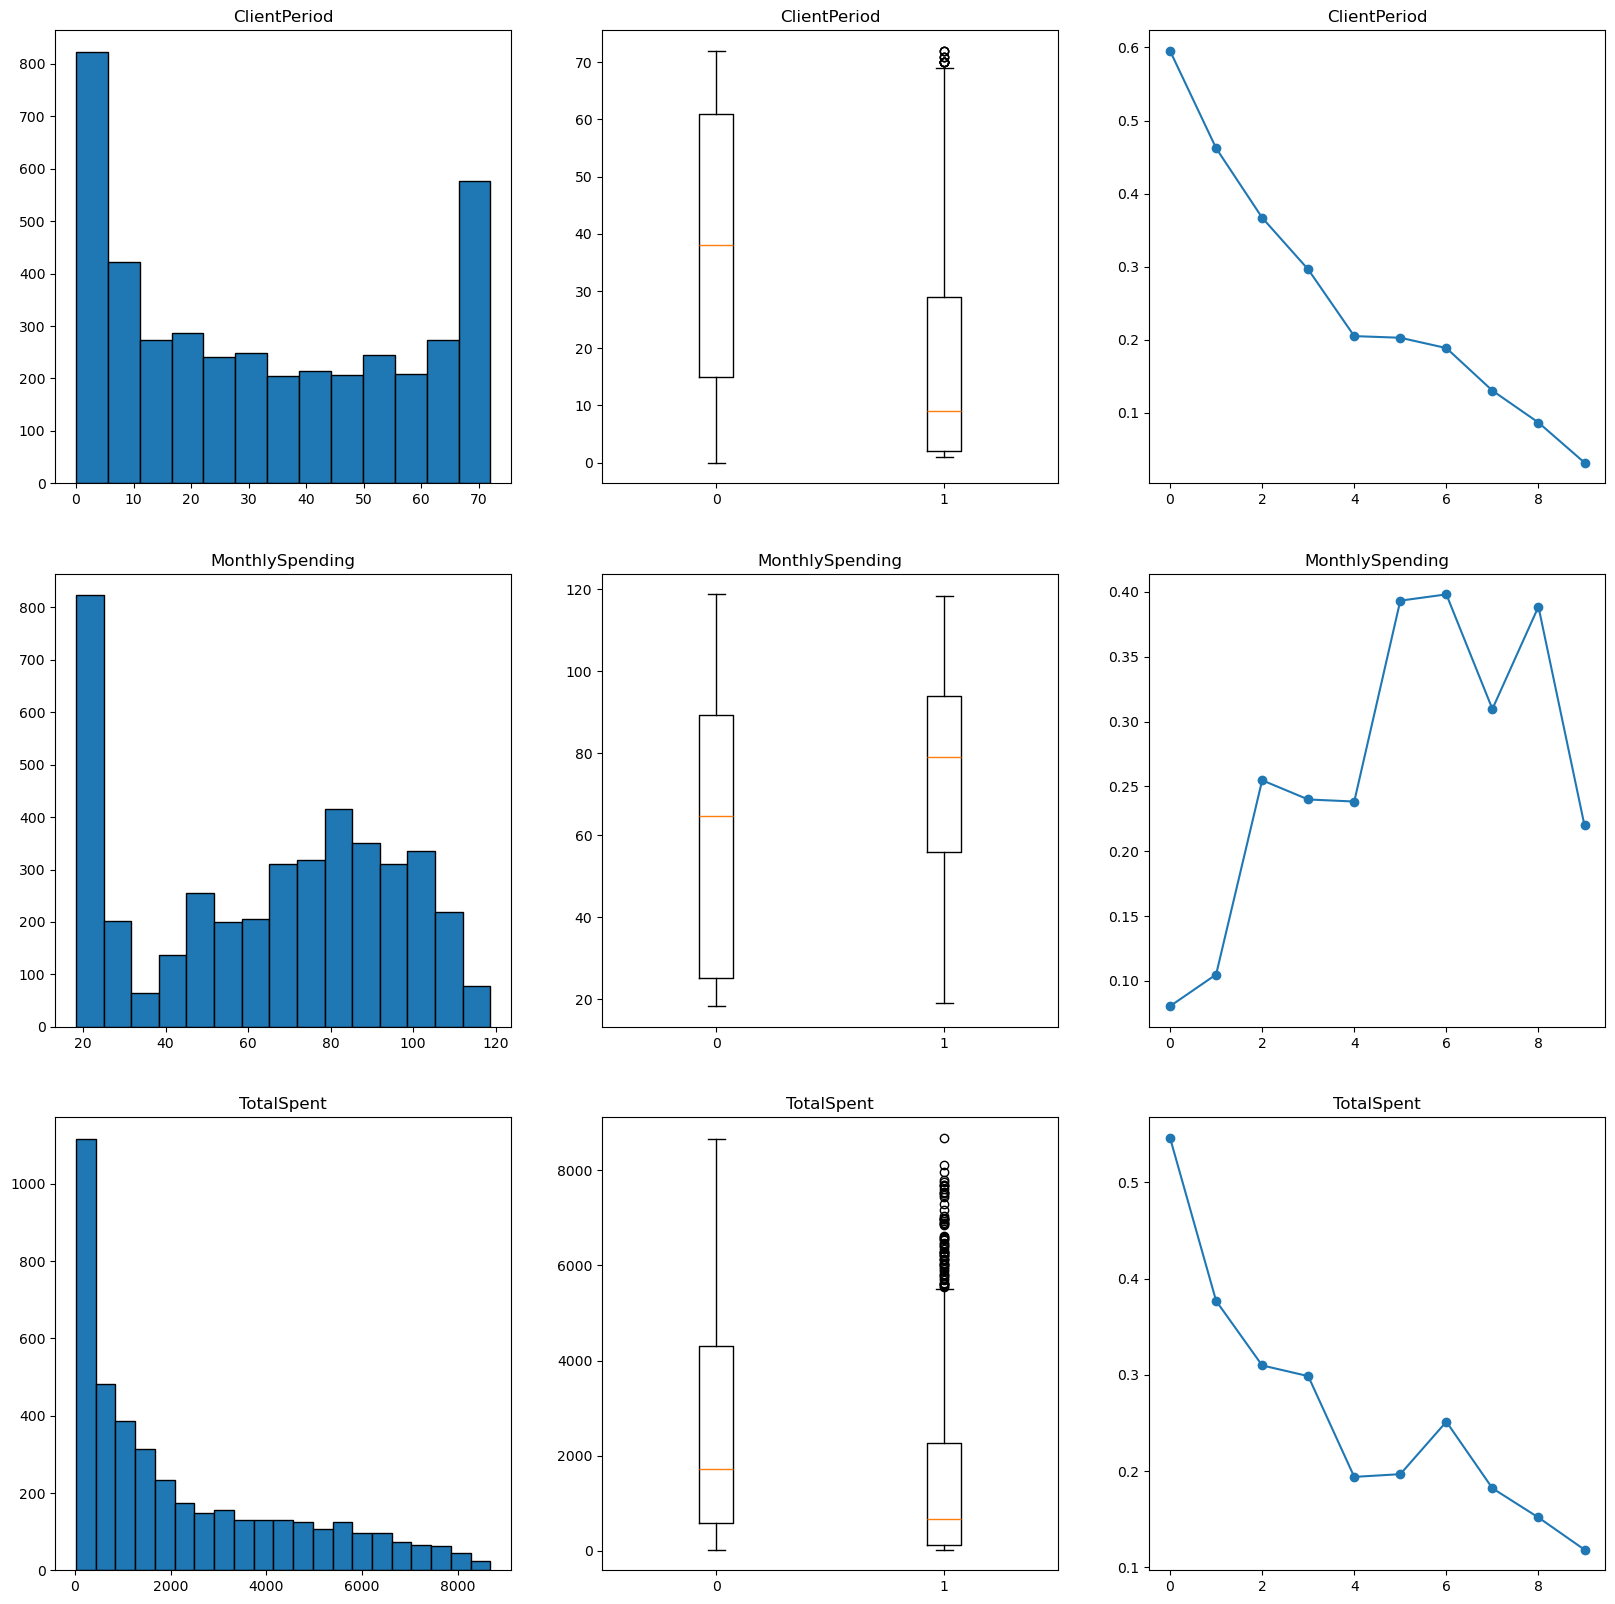

                 ClientPeriod  MonthlySpending  TotalSpent
ClientPeriod         1.000000         0.252919    0.825262
MonthlySpending      0.252919         1.000000    0.655686
TotalSpent           0.825262         0.655686    1.000000


In [26]:
# Работа с числовыми признаками

fig, axes = plt.subplots(3, 3, figsize=(20, 20))

y_1 = X_train.loc[y_train == 0]
y_2 = X_train.loc[y_train == 1]

for axis, col in zip(axes, X_train[num_cols].columns):
    counts = X_train[col]
    axis[0].set_title(col)
    axis[0].hist(counts, bins='fd', edgecolor='black')

    counts_1 = y_1[col]
    counts_2 = y_2[col]
    axis[1].set_title(col)
    axis[1].boxplot([counts_1, counts_2])
    axis[1].set_xticklabels([0, 1])

    bins = pd.qcut(X_train.join(y_train)[col], 10, duplicates='drop')
    churn_rate = X_train.join(y_train).groupby(bins)[y_train.name].mean()

    axis[2].plot(range(len(churn_rate)), churn_rate, marker='o') # Вероятность ухода клиента
    axis[2].set_title(col)

plt.show()


print(X_train[['ClientPeriod', 'MonthlySpending', 'TotalSpent']].corr()) # Видно, что признаки сильно коррелируют, удалим TotalSpent

In [27]:
X_train = X_train.drop(columns=['TotalSpent'])
num_cols = num_cols[:-1]

X_train

,ClientPeriod,MonthlySpending,Sex,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod
1835,59,20.20,Male,0,No,No,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic)
1799,1,29.95,Female,0,No,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,No,Bank transfer (automatic)
5199,1,19.70,Male,0,Yes,Yes,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check
5273,60,104.35,Male,1,Yes,No,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Electronic check
1259,12,96.00,Female,0,No,No,Yes,No,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1180,34,75.55,Male,1,Yes,No,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check
3441,15,19.40,Female,0,No,No,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Bank transfer (automatic)
1344,10,72.15,Male,0,No,No,Yes,Yes,DSL,No,No,No,No,Yes,Yes,Month-to-month,Yes,Credit card (automatic)
4623,37,104.50,Male,0,No,No,Yes,Yes,Fiber optic,No,Yes,No,Yes,Yes,Yes,One year,Yes,Credit card (automatic)


In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train[num_cols])
X_train[num_cols] = scaler.transform(X_train[num_cols])

X_train

,ClientPeriod,MonthlySpending,Sex,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod
1835,1.077778,-1.475594,Male,0,No,No,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic)
1799,-1.279732,-1.152494,Female,0,No,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,No,Bank transfer (automatic)
5199,-1.279732,-1.492163,Male,0,Yes,Yes,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check
5273,1.118424,1.313009,Male,1,Yes,No,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Electronic check
1259,-0.832618,1.036303,Female,0,No,No,Yes,No,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1180,0.061610,0.358621,Male,1,Yes,No,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check
3441,-0.710678,-1.502104,Female,0,No,No,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Bank transfer (automatic)
1344,-0.913911,0.245950,Male,0,No,No,Yes,Yes,DSL,No,No,No,No,Yes,Yes,Month-to-month,Yes,Credit card (automatic)
4623,0.183550,1.317980,Male,0,No,No,Yes,Yes,Fiber optic,No,Yes,No,Yes,Yes,Yes,One year,Yes,Credit card (automatic)


In [29]:
# Работа с категориальными признаками

# Признаки с No internet service делаем бинарными
bin_cols = [
    'HasOnlineSecurityService',
    'HasOnlineBackup',
    'HasDeviceProtection',
    'HasTechSupportAccess',
    'HasOnlineTV',
    'HasMovieSubscription',
]
for col in bin_cols:
    X_train[col] = X_train[col].map(lambda x: 1 if x == 'Yes' else 0)

X_train

,ClientPeriod,MonthlySpending,Sex,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod
1835,1.077778,-1.475594,Male,0,No,No,Yes,No,No,0,0,0,0,0,0,Two year,Yes,Bank transfer (automatic)
1799,-1.279732,-1.152494,Female,0,No,No,No,No phone service,DSL,0,1,0,0,0,0,Month-to-month,No,Bank transfer (automatic)
5199,-1.279732,-1.492163,Male,0,Yes,Yes,Yes,No,No,0,0,0,0,0,0,Month-to-month,No,Mailed check
5273,1.118424,1.313009,Male,1,Yes,No,Yes,Yes,Fiber optic,0,1,1,0,1,1,One year,Yes,Electronic check
1259,-0.832618,1.036303,Female,0,No,No,Yes,No,Fiber optic,0,0,1,0,1,1,Month-to-month,Yes,Electronic check
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1180,0.061610,0.358621,Male,1,Yes,No,Yes,Yes,Fiber optic,0,0,0,0,0,0,Month-to-month,Yes,Electronic check
3441,-0.710678,-1.502104,Female,0,No,No,Yes,No,No,0,0,0,0,0,0,Month-to-month,No,Bank transfer (automatic)
1344,-0.913911,0.245950,Male,0,No,No,Yes,Yes,DSL,0,0,0,0,1,1,Month-to-month,Yes,Credit card (automatic)
4623,0.183550,1.317980,Male,0,No,No,Yes,Yes,Fiber optic,0,1,0,1,1,1,One year,Yes,Credit card (automatic)


In [30]:
from sklearn.preprocessing import LabelEncoder

# Кодируем бинарные признаки
label_encoder_map = {
    'Sex': LabelEncoder(),
    'IsSeniorCitizen': LabelEncoder(),
    'HasPartner': LabelEncoder(),
    'HasChild': LabelEncoder(),
    'HasPhoneService': LabelEncoder()
}

for feature, encoder in label_encoder_map.items():
    encoder.fit(X_train[feature])
    X_train[feature] = encoder.transform(X_train[feature])

X_train.head(3)

,ClientPeriod,MonthlySpending,Sex,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod
1835,1.077778,-1.475594,1,0,0,0,1,No,No,0,0,0,0,0,0,Two year,Yes,Bank transfer (automatic)
1799,-1.279732,-1.152494,0,0,0,0,0,No phone service,DSL,0,1,0,0,0,0,Month-to-month,No,Bank transfer (automatic)
5199,-1.279732,-1.492163,1,0,1,1,1,No,No,0,0,0,0,0,0,Month-to-month,No,Mailed check


In [31]:
# Оставшиеся категориальные признаки кодируем OneHot энкодером
from sklearn.preprocessing import OneHotEncoder

other_features = sorted(list(set(cat_cols) - set(bin_cols) - set(label_encoder_map.keys())))


encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
ohe_encoded = encoder.fit_transform(X_train[other_features])

ohe_df = pd.DataFrame(
    ohe_encoded,
    columns=encoder.get_feature_names_out(other_features),
    index=X_train.index
)

X_train = X_train.drop(columns=other_features).join(ohe_df)

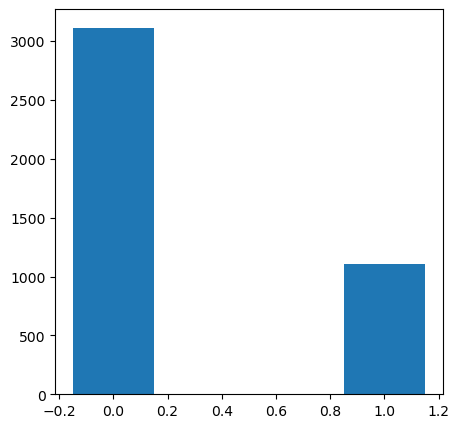

In [32]:
# 2

fig = plt.figure(figsize=(5, 5))
churn_count = y_train.groupby(by=y_train.values).size()
plt.bar(churn_count.index, churn_count.values, width=0.3)
plt.show() # Элементов 0-го класса примерно в 3 раза больше чем первого

In [66]:
# Функции которые выполняют все преобразования с данными
bin_cols = ['HasOnlineSecurityService','HasOnlineBackup','HasDeviceProtection', 'HasTechSupportAccess','HasOnlineTV','HasMovieSubscription']
label_cols = ['Sex','IsSeniorCitizen','HasPartner','HasChild','HasPhoneService']
other_features = sorted(list(set(cat_cols) - set(bin_cols) - set(label_cols)))


def fit_transform_train(X_train):
    X = X_train.copy()
    spent_mean = X["TotalSpent"].replace(" ", np.nan).astype(float).mean()
    X["TotalSpent"] = X["TotalSpent"].replace(" ", spent_mean).astype(float)
    X = X.drop(columns=["TotalSpent"])
    for c in bin_cols:
        X[c] = (X[c] == "Yes").astype(int)
    les = {}
    for c in label_cols:
        le = LabelEncoder()
        X[c] = le.fit_transform(X[c])
        les[c] = le
    ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
    ohe_arr = ohe.fit_transform(X[other_features])
    ohe_df = pd.DataFrame(
        ohe_arr,
        columns=ohe.get_feature_names_out(other_features),
        index=X.index
    )
    X = X.drop(columns=other_features).join(ohe_df)
    scaler = StandardScaler()
    X[['ClientPeriod','MonthlySpending']] = scaler.fit_transform(
        X[['ClientPeriod','MonthlySpending']]
    )
    return X, spent_mean, les, ohe, scaler


def transform_any(X_any, spent_mean, les, ohe, scaler):
    X = X_any.copy()
    X["TotalSpent"] = X["TotalSpent"].replace(" ", spent_mean).astype(float)
    X = X.drop(columns=["TotalSpent"])
    for c in bin_cols:
        X[c] = (X[c] == "Yes").astype(int)
    for c, le in les.items():
        X[c] = le.transform(X[c])
    ohe_arr = ohe.transform(X[other_features])
    ohe_df = pd.DataFrame(
        ohe_arr,
        columns=ohe.get_feature_names_out(other_features),
        index=X.index
    )
    X = X.drop(columns=other_features).join(ohe_df)
    X[['ClientPeriod','MonthlySpending']] = scaler.transform(
        X[['ClientPeriod','MonthlySpending']]
    )
    return X


df = pd.read_csv('./train.csv')
y = df.pop('Churn')
X = df.copy(deep=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
X_train, spent_mean, les, ohe, scaler = fit_transform_train(X_train)
X_test = transform_any(X_test, spent_mean, les, ohe, scaler)

## Применение линейных моделей (3 балла)

1) Обработайте данные для того, чтобы к ним можно было применить LogisticRegression. Т.е. отнормируйте числовые признаки, а категориальные закодируйте с помощью one-hot-encoding'а.

2) С помощью кроссвалидации или разделения на train/valid выборку протестируйте разные значения гиперпараметра C и выберите лучший (можно тестировать С=100, 10, 1, 0.1, 0.01, 0.001) по метрике ROC-AUC.

Если вы разделяете на train/valid, то используйте LogisticRegressionCV. Он сам при вызове .fit() подберет параметр С. (не забудьте передать scroing='roc_auc', чтобы при кроссвалидации сравнивались значения этой метрики, и refit=True, чтобы при потом модель обучилась на всем датасете с лучшим параметром C).


(более сложный вариант) Если вы будете использовать кроссвалидацию, то преобразования данных и LogisticRegression нужно соединить в один Pipeline с помощью make_pipeline, как это делалось во втором семинаре. Потом pipeline надо передать в GridSearchCV. Для one-hot-encoding'a можно испльзовать комбинацию LabelEncoder + OneHotEncoder (сначала превращаем строчки в числа, а потом числа првращаем в one-hot вектора.)

In [65]:
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder, OneHotEncoder
from sklearn.pipeline import make_pipeline

In [68]:
# YOUR CODE
from sklearn.metrics import roc_auc_score


model = LogisticRegression(class_weight="balanced", max_iter=1000)
param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l2"]
}

grid = GridSearchCV(model, param_grid, scoring="roc_auc", cv=5)
grid.fit(X_train, y_train)
model_linear = grid.best_estimator_
print(grid.best_params_)

roc_auc_score(model_linear.predict(X_test), y_test)

{'C': 0.1, 'penalty': 'l2'}


np.float64(0.7122419079041529)

Выпишите какое лучшее качество и с какими параметрами вам удалось получить (0.7122419079041529, {'C': 0.1, 'penalty': 'l2'})

## Применение градиентного бустинга (2 балла)

Если вы хотите получить баллы за точный ответ, то стоит попробовать градиентный бустинг. Часто градиентный бустинг с параметрами по умолчанию даст вам 80% результата за 0% усилий.

Мы будем использовать catboost, поэтому нам не надо кодировать категориальные признаки. Catboost сделает это сам (в .fit() надо передать cat_features=cat_cols). А численные признаки нормировать для моделей, основанных на деревьях не нужно.

1) Разделите выборку на train/valid. Протестируйте catboost cо стандартными параметрами.

2) Протестируйте разные занчения параметров количества деревьев и learning_rate'а и выберите лучшую по метрике ROC-AUC комбинацию.

(Дополнительно) Есть некоторые сложности с тем, чтобы использовать CatBoostClassifier вместе с GridSearchCV, поэтому мы не просим использовать кроссвалидацию. Но можете попробовать)

In [69]:
# YOUR CODE
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score

grid_iters = [300, 600, 1000]
grid_lr = [0.03, 0.05, 0.1]

best_auc = -1
best_params = None

for it in grid_iters:
    for lr in grid_lr:
        model = CatBoostClassifier(
            loss_function="Logloss",
            eval_metric="AUC",
            iterations=it,
            learning_rate=lr,
            depth=6,
            random_seed=10,
            auto_class_weights="Balanced",
            verbose=False
        )

        model.fit(X_train, y_train, eval_set=(X_test, y_test), use_best_model=True)

        y_proba = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)

        if auc > best_auc:
            best_auc = auc
            best_params = {"iterations": it, "learning_rate": lr}
            best_catboost_model = model




print(best_auc)
print(best_params)

0.8527435846877554
{'iterations': 300, 'learning_rate': 0.1}


Выпишите, какое лучшее качество и с какими параметрами вам удалось получить

ВАШ ОТВЕТ 0.8527435846877554 {'iterations': 300, 'learning_rate': 0.1}

# Предсказания

In [42]:
best_model = best_catboost_model

In [63]:
X_test = transform_any(pd.read_csv('./test.csv'), spent_mean, les, ohe, scaler)
submission = pd.read_csv('./submission.csv')

submission['Churn'] = best_model.predict_proba(X_test)[:,1]

# используйте best_model.predict_proba(X_test), не забудьте выделить вероятность класса 1.
submission.to_csv('./my_submission.csv')

# Score 0.849415053485441


Лучшее решение отправьте в Stepik.